<a href="https://colab.research.google.com/github/sasya025/Travclan/blob/main/Hotel_booking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (30000, 24)

Columns:
['customer_id', 'property_id', 'city', 'star_rating', 'booking_date', 'check_in_date', 'check_out_date', 'room_type', 'num_rooms_booked', 'stay_type', 'booking_channel', 'booking_value', 'costprice', 'markup', 'selling_price', 'payment_method', 'refund_status', 'refund_amount', 'channel_of_booking', 'booking_status', 'travel_date', 'cashback', 'coupon_redeem', 'Coupon USed?']

========== KPI ==========
Total Bookings: 30000
Confirmed: 21672
Cancelled: 6070
Failed: 2258
Cancellation Rate: 20.23 %
Total Revenue: 885144555
Total Profit: 208899732


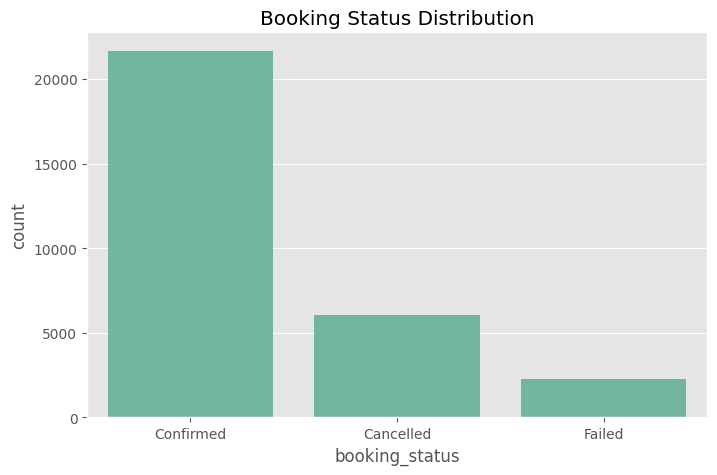

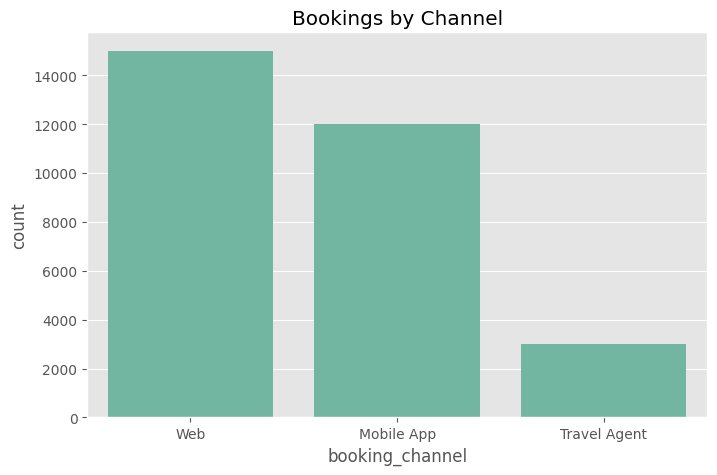


Revenue by Channel
booking_channel
Web             443990337
Mobile App      353334888
Travel Agent     87819330
Name: selling_price, dtype: int64


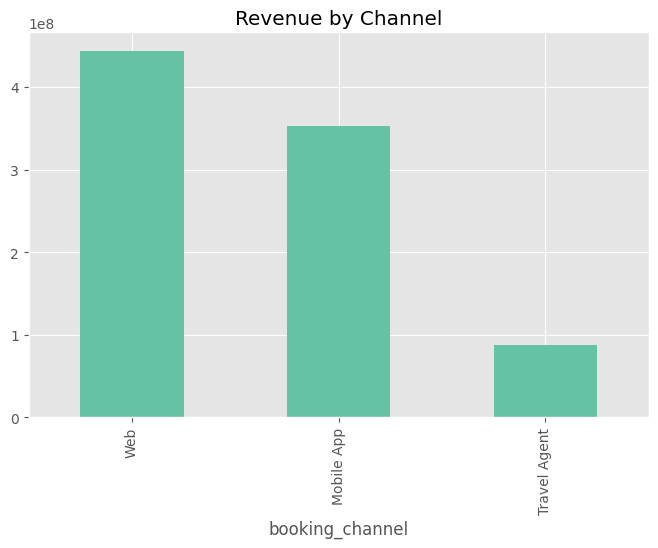

booking_status   Cancelled  Confirmed     Failed
booking_channel                                 
Mobile App       21.558831  67.541011  10.900158
Travel Agent     27.926421  66.187291   5.886288
Web              17.638824  77.208186   5.152990


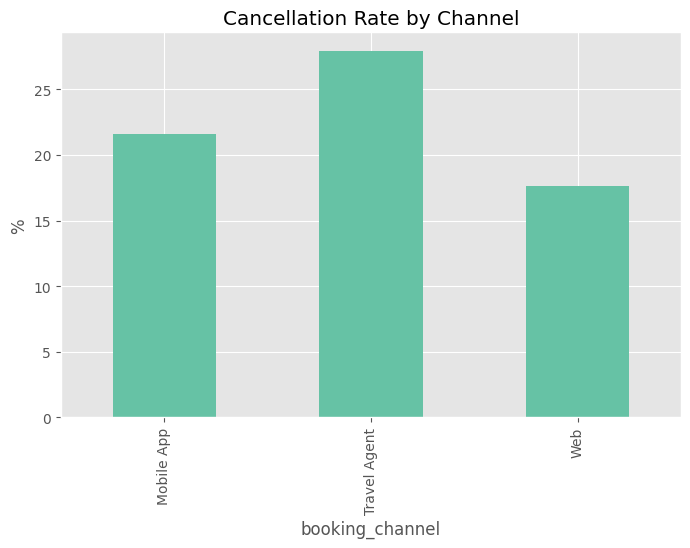

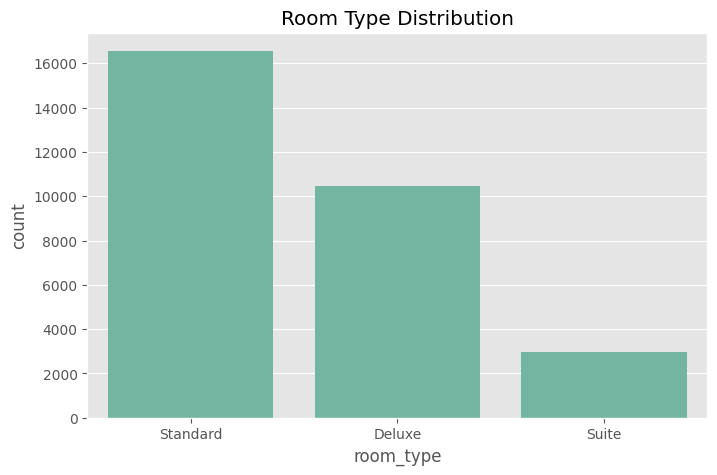

room_type
Deluxe      307746286
Standard    489570753
Suite        87827516
Name: selling_price, dtype: int64


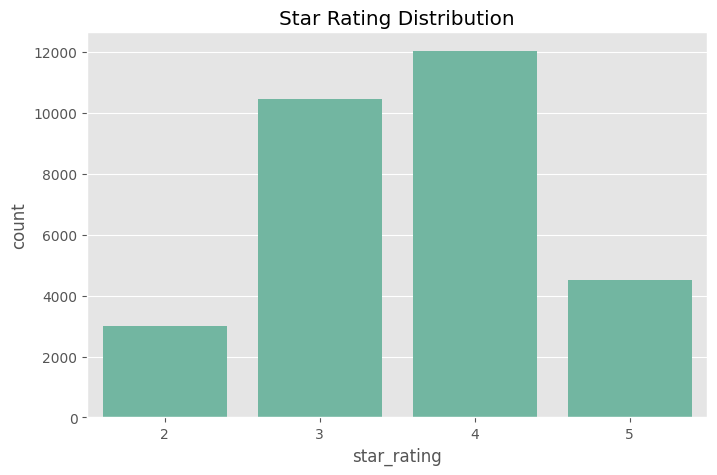

star_rating
2     88492254
3    310134032
4    354841176
5    131677093
Name: selling_price, dtype: int64

Top Cities by Revenue
city
Chicago          91004975
Los Angeles      90702390
San Francisco    90082109
Las Vegas        88816802
New York         88592659
Orlando          88502302
Boston           88329320
Miami            86844493
Seattle          86561083
Dallas           85708422
Name: selling_price, dtype: int64


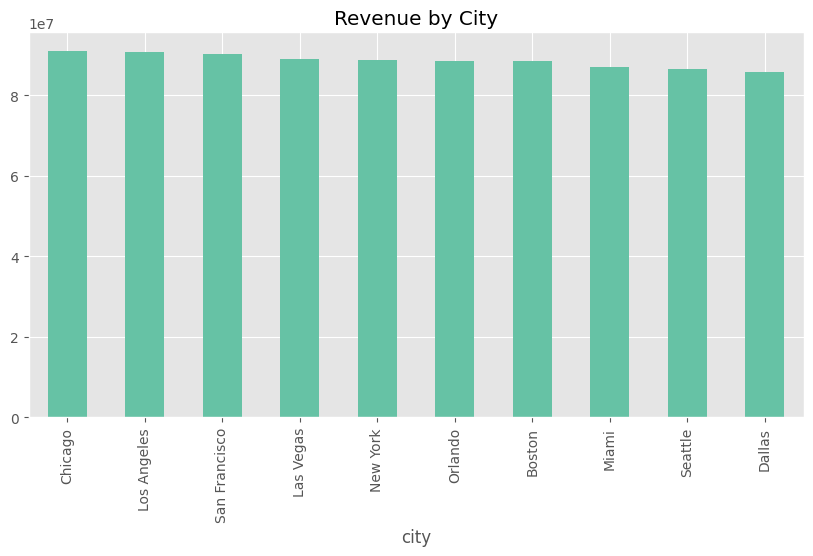

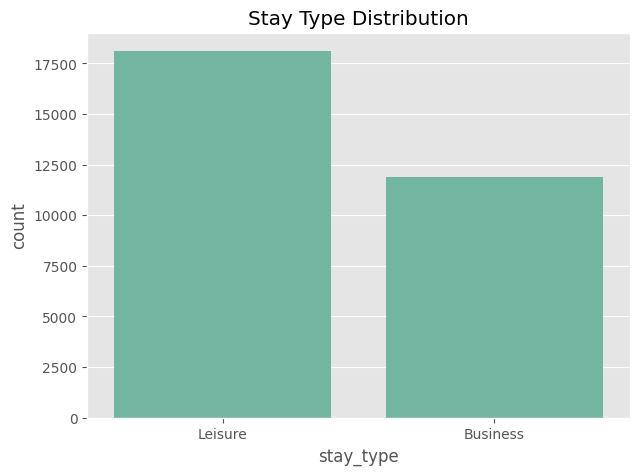


Cancellation by Payment Method
booking_status  Cancelled  Confirmed    Failed
payment_method                                
Bank Transfer   19.177708  73.173064  7.649228
Credit Card     20.568607  71.823278  7.608115
Debit Card      20.347231  72.195186  7.457583
PayPal          20.806962  71.795886  7.397152

Refund Summary
refund_status
No     0.000000e+00
Yes    9.628151e+06
Name: refund_amount, dtype: float64


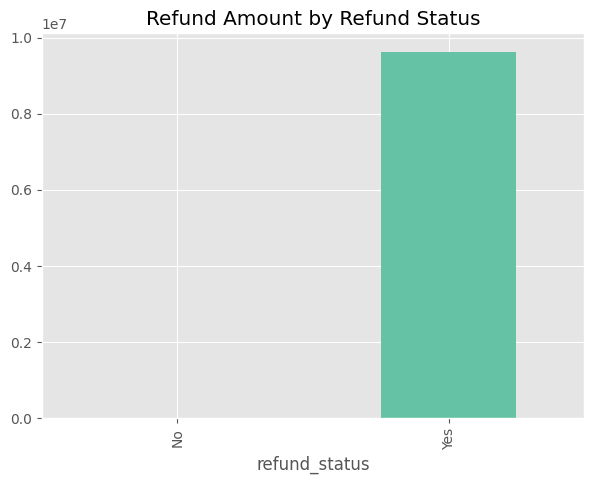

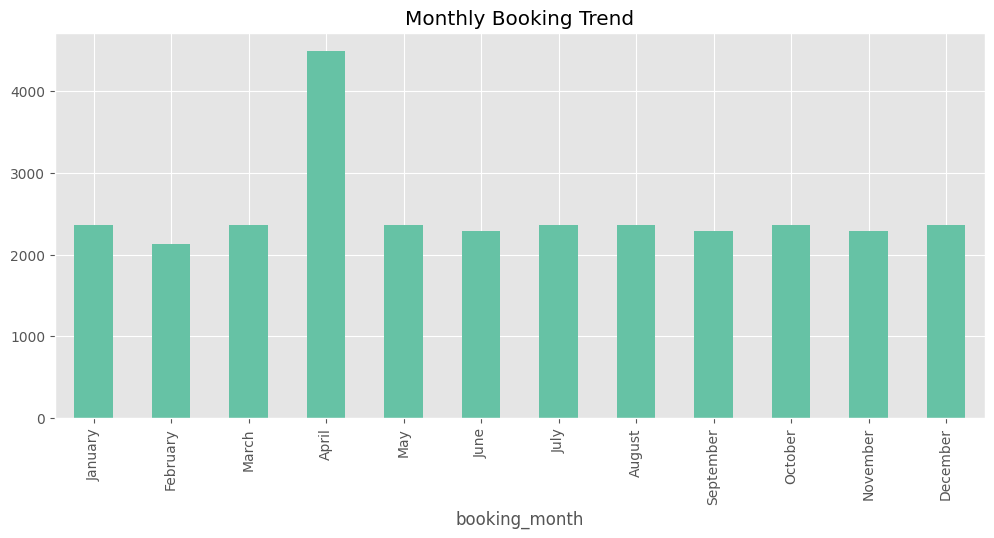

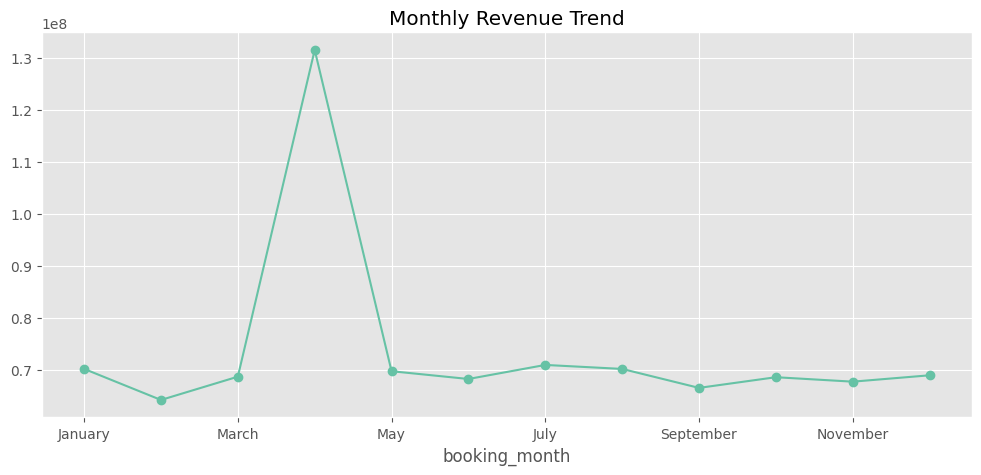

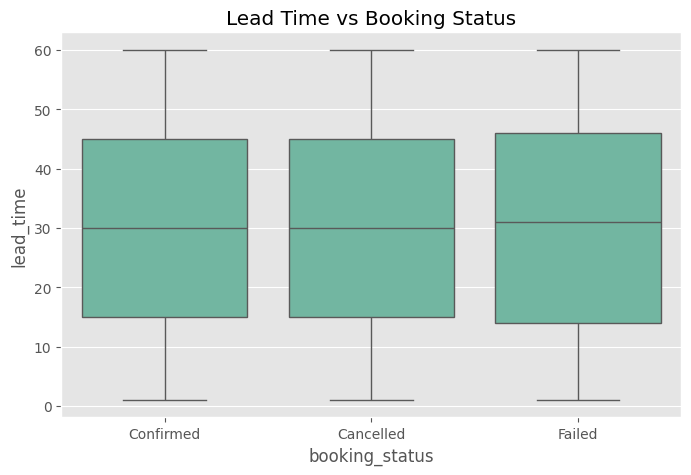

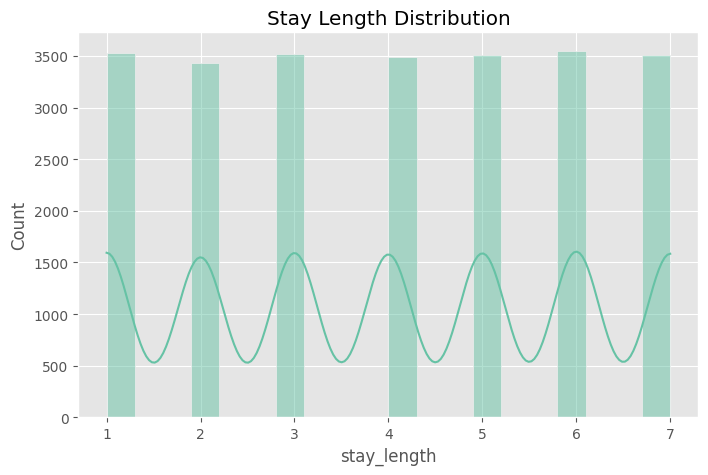


Profit Summary
count    30000.00000
mean      6963.32440
std       2860.10657
min       1181.00000
25%       4661.75000
50%       7021.50000
75%       9399.00000
max      11800.00000
Name: profit, dtype: float64


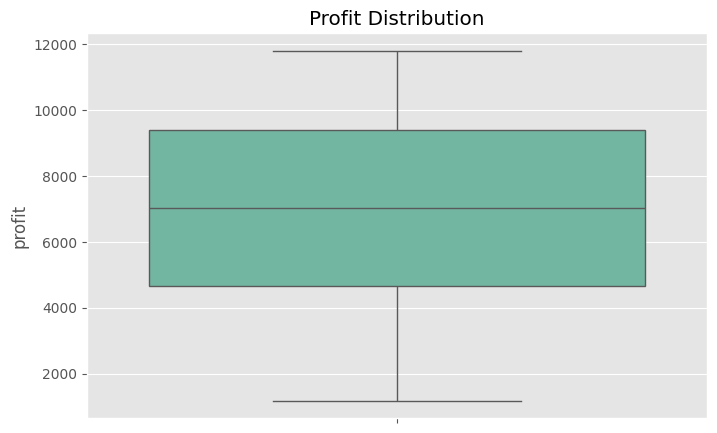


Average Selling Price by Coupon Usage
Coupon USed?
No     29467.933675
Yes    29646.610367
Name: selling_price, dtype: float64


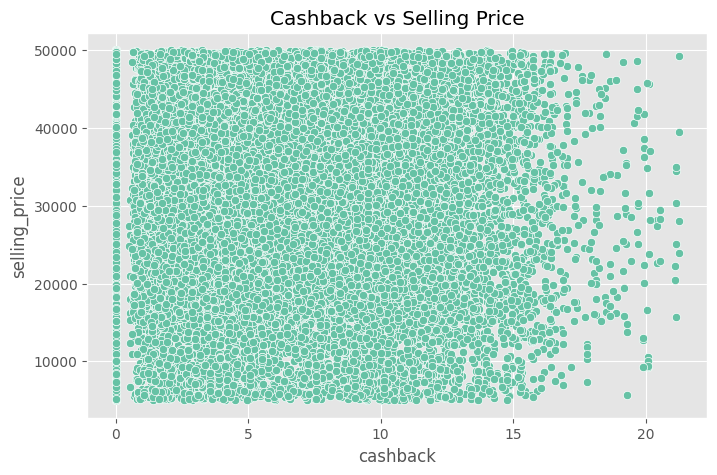

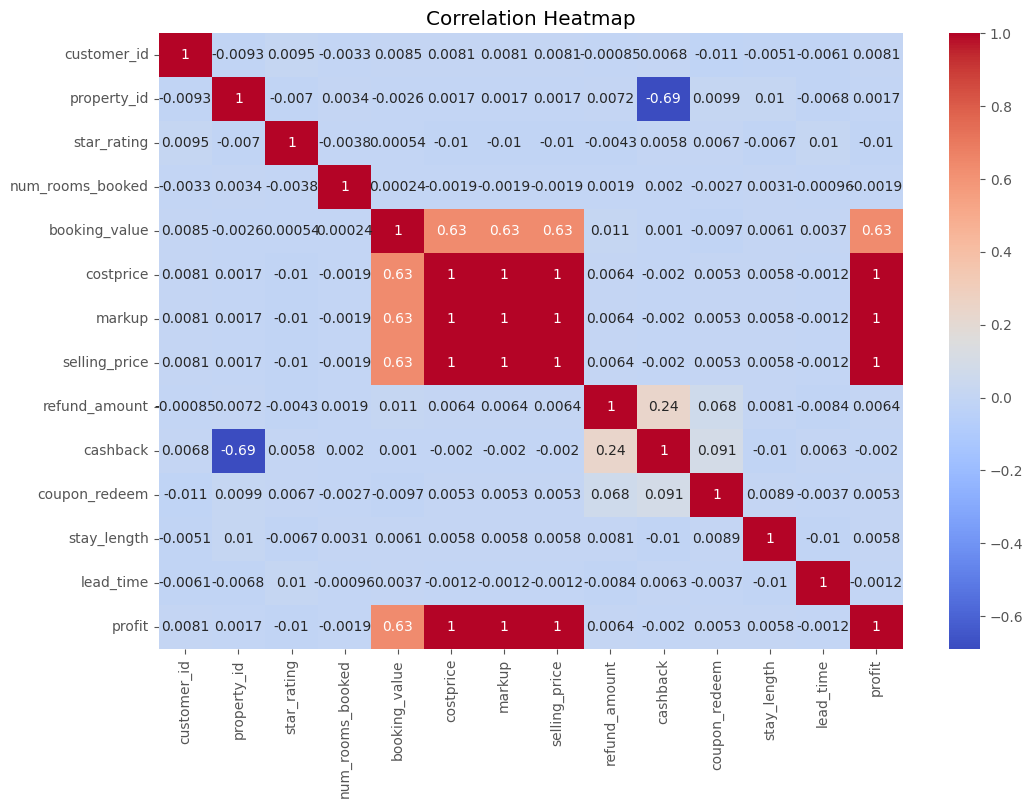


===== BUSINESS INSIGHTS =====

1. Identify which booking channel generates the highest revenue.

2. Identify which booking channel has the highest cancellation rate.

3. Compare cancellation rates across room types.

4. Compare performance across star ratings.

5. Analyze impact of coupons and cashback.

6. Check whether long lead times increase cancellations.

7. Identify cities generating maximum revenue.

8. Analyze refund behavior and financial impact.



In [3]:
# ==========================================
# TRAVCLAN HOTEL BOOKING ANALYSIS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("Set2")

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("Hotel_bookings_final.csv")

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

# ==========================================
# DATE CONVERSION
# ==========================================

date_cols = [
    'booking_date',
    'check_in_date',
    'check_out_date',
    'travel_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# ==========================================
# FEATURE ENGINEERING
# ==========================================

df['stay_length'] = (
    df['check_out_date'] -
    df['check_in_date']
).dt.days

df['lead_time'] = (
    df['check_in_date'] -
    df['booking_date']
).dt.days

df['booking_month'] = df['booking_date'].dt.month_name()

# ==========================================
# KPI SECTION
# ==========================================

total_bookings = len(df)

confirmed = len(
    df[df['booking_status'] == 'Confirmed']
)

cancelled = len(
    df[df['booking_status'] == 'Cancelled']
)

failed = len(
    df[df['booking_status'] == 'Failed']
)

cancel_rate = round(
    cancelled/total_bookings*100,
    2
)

total_revenue = df['selling_price'].sum()

profit = (
    df['selling_price'] -
    df['costprice']
).sum()

print("\n========== KPI ==========")

print("Total Bookings:", total_bookings)
print("Confirmed:", confirmed)
print("Cancelled:", cancelled)
print("Failed:", failed)

print("Cancellation Rate:", cancel_rate,"%")

print("Total Revenue:", round(total_revenue,2))
print("Total Profit:", round(profit,2))

# ==========================================
# BOOKING STATUS
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='booking_status'
)

plt.title("Booking Status Distribution")
plt.show()

# ==========================================
# BOOKING CHANNEL
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='booking_channel',
    order=df['booking_channel'].value_counts().index
)

plt.title("Bookings by Channel")
plt.show()

# ==========================================
# CHANNEL REVENUE
# ==========================================

channel_rev = (
    df.groupby('booking_channel')
    ['selling_price']
    .sum()
    .sort_values(ascending=False)
)

print("\nRevenue by Channel")
print(channel_rev)

channel_rev.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Revenue by Channel")
plt.show()

# ==========================================
# CANCELLATION RATE BY CHANNEL
# ==========================================

cancel_channel = pd.crosstab(
    df['booking_channel'],
    df['booking_status'],
    normalize='index'
)*100

print(cancel_channel)

cancel_channel['Cancelled'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Cancellation Rate by Channel")
plt.ylabel("%")
plt.show()

# ==========================================
# ROOM TYPE ANALYSIS
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='room_type',
    order=df['room_type'].value_counts().index
)

plt.title("Room Type Distribution")
plt.show()

room_rev = (
    df.groupby('room_type')
    ['selling_price']
    .sum()
)

print(room_rev)

# ==========================================
# STAR RATING ANALYSIS
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='star_rating'
)

plt.title("Star Rating Distribution")
plt.show()

rating_rev = (
    df.groupby('star_rating')
    ['selling_price']
    .sum()
)

print(rating_rev)

# ==========================================
# CITY ANALYSIS
# ==========================================

top_city = (
    df.groupby('city')
    ['selling_price']
    .sum()
    .sort_values(ascending=False)
)

print("\nTop Cities by Revenue")
print(top_city)

top_city.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Revenue by City")
plt.show()

# ==========================================
# STAY TYPE ANALYSIS
# ==========================================

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='stay_type'
)

plt.title("Stay Type Distribution")
plt.show()

# ==========================================
# PAYMENT METHOD ANALYSIS
# ==========================================

payment_cancel = pd.crosstab(
    df['payment_method'],
    df['booking_status'],
    normalize='index'
)*100

print("\nCancellation by Payment Method")
print(payment_cancel)

# ==========================================
# REFUND ANALYSIS
# ==========================================

refund = (
    df.groupby('refund_status')
    ['refund_amount']
    .sum()
)

print("\nRefund Summary")
print(refund)

refund.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Refund Amount by Refund Status")
plt.show()

# ==========================================
# MONTHLY BOOKINGS
# ==========================================

month_order = [
    'January','February','March',
    'April','May','June',
    'July','August','September',
    'October','November','December'
]

monthly_bookings = (
    df.groupby('booking_month')
    .size()
)

monthly_bookings = monthly_bookings.reindex(month_order)

monthly_bookings.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Monthly Booking Trend")
plt.show()

# ==========================================
# MONTHLY REVENUE
# ==========================================

monthly_revenue = (
    df.groupby('booking_month')
    ['selling_price']
    .sum()
)

monthly_revenue = monthly_revenue.reindex(month_order)

monthly_revenue.plot(
    marker='o',
    figsize=(12,5)
)

plt.title("Monthly Revenue Trend")
plt.show()

# ==========================================
# LEAD TIME ANALYSIS
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='booking_status',
    y='lead_time'
)

plt.title("Lead Time vs Booking Status")
plt.show()

# ==========================================
# STAY LENGTH ANALYSIS
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['stay_length'],
    bins=20,
    kde=True
)

plt.title("Stay Length Distribution")
plt.show()

# ==========================================
# PROFIT ANALYSIS
# ==========================================

df['profit'] = (
    df['selling_price'] -
    df['costprice']
)

print("\nProfit Summary")
print(df['profit'].describe())

plt.figure(figsize=(8,5))

sns.boxplot(
    y=df['profit']
)

plt.title("Profit Distribution")
plt.show()

# ==========================================
# COUPON ANALYSIS
# ==========================================

coupon = (
    df.groupby('Coupon USed?')
    ['selling_price']
    .mean()
)

print("\nAverage Selling Price by Coupon Usage")
print(coupon)

# ==========================================
# CASHBACK ANALYSIS
# ==========================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='cashback',
    y='selling_price'
)

plt.title("Cashback vs Selling Price")
plt.show()

# ==========================================
# CORRELATION HEATMAP
# ==========================================

numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# TOP INSIGHTS
# ==========================================

print("\n===== BUSINESS INSIGHTS =====")

print("""
1. Identify which booking channel generates the highest revenue.

2. Identify which booking channel has the highest cancellation rate.

3. Compare cancellation rates across room types.

4. Compare performance across star ratings.

5. Analyze impact of coupons and cashback.

6. Check whether long lead times increase cancellations.

7. Identify cities generating maximum revenue.

8. Analyze refund behavior and financial impact.
""")